# LSE ST451: Bayesian Machine Learning
## Author: Kostas Kalogeropoulos

## Week 1: Bayesian Inference Concepts

Topics covered

 - Introduction to Python, e.g.working with arrays, basic operation and plotting
 - Pseudo-Random numbers
 - Bayesian Inference (Point and Interval Estimation, Forecasting) with Monte Carlo

### Basic operations in Python

In this first session we cover basic math operations. 

We start with an example of basic arithmetic.

In [1]:
a=3
b=2*a
print(b)
print(a*b)

6
18


Next we will load the library **NumPy**

In [2]:
import numpy as np

and see how we can handle 1d arrays

In [3]:
a = np.array([0, 1, 2, 3])
print(a,a.ndim, a.shape, len(a))

[0 1 2 3] 1 (4,) 4


and 2d arrays

In [4]:
b = np.array([[0, 1, 2], [3, 4, 5]])
print(b,b.ndim, b.shape, len(b))

[[0 1 2]
 [3 4 5]] 2 (2, 3) 2


We continue with some standard commands to create arrays and perform operations on them. The command linspace(start,stop,N), returns N evenly spaced values in the interval [start, stop]

In [5]:
x = np.linspace(0, 3, 20)
y = np.linspace(0, 9, 20)
print('x',x)
print('y',y)

x [0.         0.15789474 0.31578947 0.47368421 0.63157895 0.78947368
 0.94736842 1.10526316 1.26315789 1.42105263 1.57894737 1.73684211
 1.89473684 2.05263158 2.21052632 2.36842105 2.52631579 2.68421053
 2.84210526 3.        ]
y [0.         0.47368421 0.94736842 1.42105263 1.89473684 2.36842105
 2.84210526 3.31578947 3.78947368 4.26315789 4.73684211 5.21052632
 5.68421053 6.15789474 6.63157895 7.10526316 7.57894737 8.05263158
 8.52631579 9.        ]


Some commands to access 1d array elements and compute sums and averages on them

In [6]:
y[0], y[2], y[-1], y[y>7], y[0:3], np.mean(y), np.sum(y[y>8])

(0.0,
 0.9473684210526315,
 9.0,
 array([7.10526316, 7.57894737, 8.05263158, 8.52631579, 9.        ]),
 array([0.        , 0.47368421, 0.94736842]),
 4.5,
 25.57894736842105)

Some commands to create 2d arrays

In [7]:
np.ones((3, 3))

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [8]:
np.zeros((2, 2))

array([[0., 0.],
       [0., 0.]])

In [9]:
np.eye(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [10]:
a=np.diag(np.array([1, 2, 3, 4]))
print('a',a)

a [[1 0 0 0]
 [0 2 0 0]
 [0 0 3 0]
 [0 0 0 4]]


Some operations to access 2d array elements and compute sums and averages on them

In [11]:
a[0,0], a[2,1], a[3,3], a[2], a[:,1], a[a>2], np.sum(a), np.mean(a[3]), np.sum(a[a>1])

(1, 0, 4, array([0, 0, 3, 0]), array([0, 2, 0, 0]), array([3, 4]), 10, 1.0, 9)

### Pseudo - random numbers

Define a sequence $\{s_i\}$ and set (for some $a,b,s_0,M$)
$$
s_{i+1}=(a\; s_i \;+ \;b)  \text{mod} M.
$$

Then $U_i =\frac{s_i}{M} \;\sim\;$ Uniform$(0,1)$.

 For large $M$, the numbers obtained by the algorithm above satisfy all the properties of random samples from a Uniform$(0,1)$ distribution. They are called pseudo-random numbers.

 Given pseudo-random numbers from Uniform($0,1$) we can simulate from other known distributions.

In [12]:
a = np.random.rand(4)       # Uniform(0, 1)
print('4 uniform random numbers',a)
b = np.random.randn(10)      # Normal(0,1)
print('10 normal random numbers',b)  

4 uniform random numbers [0.336398   0.84296072 0.27480504 0.09921537]
10 normal random numbers [ 1.18817399  0.52749225  2.21016209 -0.50306056 -1.05268171  0.01604842
  0.80389051 -0.82728995 -0.11595719  1.9274128 ]


Note that you all take different numbers. Also if you repeat you will get another set of numbers.

Invdividually, everything seems to be different but collectively there is something common in all these numbers.

### Bayesian Inference with Monte Carlo 

We will draw 100 points from a Uniform Distribution and use the **sample*** mean, variance, std and median to calculate their population counterparts

In [13]:
n=100
x = np.random.rand(n)
print('mean',np.mean(x),np.sum(x)/n)
print('variance',np.var(x),np.mean(x**2)-np.mean(x)**2)
print('standard deviation',np.std(x))
print('median',np.median(x))

mean 0.5010341723688918 0.5010341723688918
variance 0.07061623146884712 0.07061623146884705
standard deviation 0.2657371473257872
median 0.5113569515138416


The calculations seem to be in the right direction but there is Monte Carlo error. This can be reduced to arbitrarily small level by simply drawing more random numbers.

In [14]:
n=100000
x = np.random.rand(n)
print('mean',np.mean(x),np.sum(x)/n)
print('variance',np.var(x),np.mean(x**2)-np.mean(x)**2)
print('standard deviation',np.std(x))
print('median',np.median(x))

mean 0.49954774288284765 0.49954774288284765
variance 0.08397272925942705 0.083972729259427
standard deviation 0.2897804846076199
median 0.498434386096887


By the way did you know the variance of Uniform[0,1] distribution? 

If you did well done!

If not, don't worry you can always find it with Monte Carlo :)

You can also find percentiles, minimums and maximums.

In [15]:
n=10000
x = np.random.rand(n)
print('min and max',np.min(x),np.max(x))
x = np.random.randn(n)
print('95% credible intervals',np.percentile(x,(2.5,97.5)))

min and max 2.0852679008642738e-05 0.9997226612966216
95% credible intervals [-1.95627091  1.94268255]


If you all want to get the same results or if you want to make sure you get the same results each time you can fix the randon seed.

In [16]:
np.random.seed(1234)  
np.random.randn(4)

array([ 0.47143516, -1.19097569,  1.43270697, -0.3126519 ])

### Plotting in Python with MatPlotLib

Finally time for some plotting. We start with scatter plots.

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt

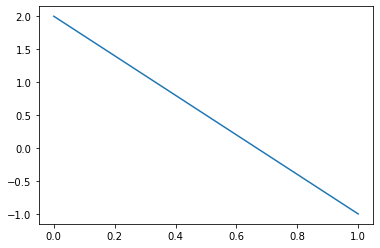

In [18]:
n = 10
x = np.linspace(0,1,n)
y = 2-3*x
plt.plot(x, y)

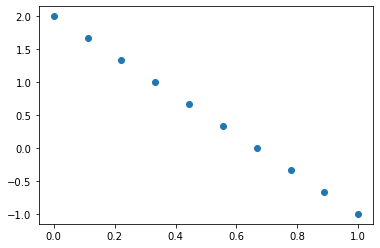

In [19]:
plt.plot(x, y,'o')

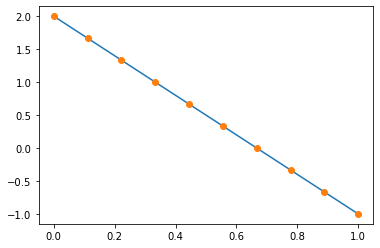

In [20]:
plt.plot(x, y)
plt.plot(x, y,'o')

and continute with histograms

(array([0.00395109, 0.00790219, 0.06716861, 0.12248393, 0.28052771,
        0.41486492, 0.38325616, 0.19755472, 0.08297298, 0.01975547]),
 array([-3.56351666, -2.93078059, -2.29804451, -1.66530844, -1.03257236,
        -0.39983629,  0.23289978,  0.86563586,  1.49837193,  2.13110801,
         2.76384408]),
 <BarContainer object of 10 artists>)

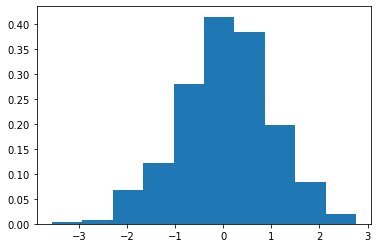

In [21]:
n=400
y = np.random.randn(n) 
plt.hist(y,density=1)

### Density estimation

Estimation of a pdf using a Kernel density estimator Draw a sample of n number of observations 
from a density f, and call the sample y. (Plot a histogram of y). Use a KDE on the sample y.
Obtain the actual density, f. Plot actual and estimated pdf

In [22]:
from scipy import stats
from scipy.stats import norm
from scipy.stats import gamma
from scipy.stats import beta

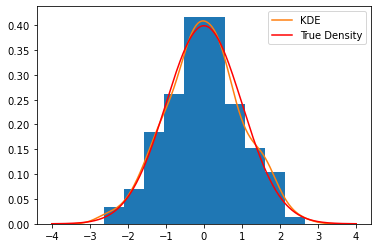

In [23]:
n=400
y = np.random.randn(n) 
estf = stats.gaussian_kde(y)
x = np.linspace(-4,4,n)
f = norm.pdf(x)
plt.hist(y,density=1)                   #histogram of sample
plt.plot(x,estf(x),label='KDE')         #Kerned Density Estimate
plt.plot(x,f,color='r',label='True Density')  #Density of Normal distribution 
plt.legend()

### Activities

Now let's put it all together with some activities relevant to Bayesian Inference

#### Activity 1

Assume that the posterior of the variable of interest $\theta$, $\pi(\theta|y)$ is the Gamma($2,1$) distribution. Provide the answers to the questions below using Monte Carlo. Verify by contrasting with the exact answers where possible.

- Provide the Bayes estimate for $\theta$.
- Give a 95\% credible interval for $\theta$.
- Calculate the posterior variance, $E[\theta^3|y]$ and $P(\theta>3|y)$.
- Give a kernel density plot for its pdf. 


In [24]:
#Activity 1
n = 10000
theta = np.random.gamma(2, 1, n)
np.median(theta), np.percentile(theta,(2.5,97.5))

(1.718791617958114, array([0.24929657, 5.63871996]))

In [25]:
np.mean((theta-np.mean(theta))**2), np.mean(theta**3), np.mean(theta>3)

(1.9904496249348183, 24.438946410372782, 0.2044)

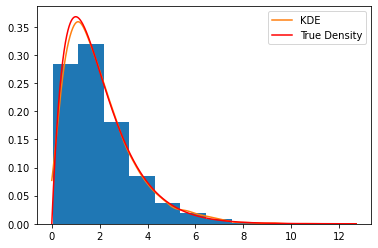

In [26]:
n = 5000
theta = np.random.gamma(2, 1, n)
estf = stats.gaussian_kde(theta)
x = np.linspace(0,max(theta)+2,n)
f = gamma.pdf(x,2,0,1)
plt.hist(theta,density=1)                   #histogram of sample
plt.plot(x,estf(x),label='KDE')         #Kerned Density Estimate
plt.plot(x,f,color='r',label='True Density')  #Density of Gamma distribution 
plt.legend()

#### Activity 2

Assume that we observe $1$ success in a Binomial experiment involving $7$ trials. Assign a Uniform($0,1$) prior on the probability of success $\theta$ and derive its posterior (you can check the lecture slides). Then, provide the answers to the below using Monte Carlo. Verify by contrasting with the exact answers where possible.

- Provide the Bayes estimate for $\theta$.
- Give a 95\% credible interval for $\theta$.
- Calculate the posterior variance, $E[1/\theta|y]$ and $P(\theta<0.2|y)$.
- Give a kernel density plot for its pdf. 

In [27]:
#Activity 2
n = 10000
theta = np.random.beta(2, 7, n)
np.mean(theta), np.percentile(theta,(2.5,97.5))

(0.21959977572176353, array([0.03167799, 0.52643207]))

In [28]:
np.mean((theta-np.mean(theta))**2), np.mean(1/theta), np.mean(theta<0.2)

(0.01712718892746531, 7.9302053560818475, 0.5091)

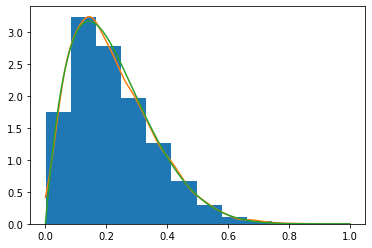

In [29]:
n = 5000
theta = np.random.beta(2, 7, n)
estf = stats.gaussian_kde(theta)
x = np.linspace(0,1,n)
f = beta.pdf(x,2,7)
plt.hist(theta,density=1)
plt.plot(x,estf(x))
plt.plot(x,f)

### Activity 3 - Bank Cashiers stuff

A bank manager wants to decide on whether she should employ additional staff in the cashiers of their branch. This is usually determined by the number of customers visiting their branch on an average day.

**Sample:** An experiment is conducted and the number of customers visiting the branch is recorded on $10$ random days and are shown below:

$X=(86,  98,  77,  94, 107,  108,  93,  72,  89,  81)$

1. Split the data into a training set (first 5 observations) and a test set (remaining observations).
2. Assign a Normal($\mu$,$100$) model and an improper prior to the training set. This gives a predictive distribution of the Normal$(\bar{X},\frac{100}{n}+100)$ See next week's course for details. Use it to obtain point forecasts for the test set. Use both Frequentist and Bayesian inference and compare their performance.
3. Repeat the previous step but with 95\% prediction intervals rather than point forecasts. 
4. For the frequentist approach one can estimate the mean $\mu$ via the MLE, $\hat{\mu}$ which is the sample mean (of the training data) as with the Bayesian approach (only because we used an improper prior). The distribution for the future data can then be the Normal($\bar{X},100$).
5. The Mean Squared Error can be used to assess the forecasts. For the prediction intervals we can just count the number of test data contained in them. 
6. Discuss the differences or similarities between the frequentist and Bayesian approaches.

In [30]:
##### Activity 3
y = np.array([86,  98,  77,  94, 107,  108,  93,  72,  89,  81])
n = 10
ntrain = 5
ytrain = y[0:ntrain]
ytest = y[ntrain:n]
estmu = np.mean(ytrain)
print('training data:',ytrain)
print('test data:',ytest)
print('Maximum Likelihood/Bayes Estimate of S.D.:', estmu)
print('test data MSE:', np.mean((ytest-estmu)**2))

training data: [ 86  98  77  94 107]
test data: [108  93  72  89  81]
Maximum Likelihood/Bayes Estimate of S.D.: 92.4
test data MSE: 160.28000000000006


In [31]:
N = 1000000
# Predict in a frequentist way: plug in the MLE and use Monte Carlo
pred_samples_freq = np.random.normal(estmu,np.sqrt(100),N)
# Get 95% frequentist prediction intervals
freqlower, frequpper = np.percentile(pred_samples_freq,(2.5,97.5))
print('Frequentist PI:',[freqlower, frequpper])
# Predict in a Bayesian way: sample from the predictive and use Monte Carlo
pred_samples_bayes = np.random.normal(estmu,np.sqrt(100+100/ntrain),N)
# Get 95% Bayesian prediction intervals
bayeslower, bayesupper = np.percentile(pred_samples_bayes,(2.5,97.5))
print('Bayesian PI:',[bayeslower, bayesupper])

print('number of test points contained in frequentist CI:', np.sum((freqlower<ytest)&(ytest<frequpper)))
print('number of test points contained in Bayesian CI:', np.sum((bayeslower<ytest)&(ytest<bayesupper)))

Frequentist PI: [72.7798384989044, 112.04640246795003]
Bayesian PI: [70.90646906197912, 113.9164990595843]
number of test points contained in frequentist CI: 4
number of test points contained in Bayesian CI: 5


The frequentist prediction intervals ignore parameter uncertainty and are therefore erroneously narrow. This is not the case for the Bayesian prediction intervals that are more relable.